# Model Evaluation

In this notebook, the trained machine learning models are evaluated in detail to understand their prediction quality and generalization performance.

The evaluation includes:
- Comparison of model performance metrics
- Error analysis
- Residual analysis
- Distribution of prediction errors
- Identification of the best-performing model for groundwater level prediction

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

#Load Dataset

In [2]:
df = pd.read_csv(
    "/content/groundwater_feature_engineered.csv",
    parse_dates=["Data Acquisition Time"]
)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (69404, 25)


,Station,Data Acquisition Time,Latitude,Longitude,Groundwater Level Telemetry 6 Hourly (meter),RL_MSL,time_diff,Year,Month,Day,...,Lag_1,Lag_4,Lag_28,RollingMean_4,RollingStd_4,Hour_sin,Hour_cos,Month_sin,Month_cos,Station_ID
0,Adakamaranahalli,2021-10-06 00:00:00,13.07,77.45,-22.50,849.0,1 days 06:00:00,2021,10,6,...,-22.71,-22.34,-22.51,-22.8625,0.419235,0.000000e+00,1.000000e+00,-1.0,-1.836970e-16,0
1,Adakamaranahalli,2021-10-06 06:00:00,13.07,77.45,-22.83,849.0,0 days 06:00:00,2021,10,6,...,-22.50,-23.16,-22.87,-22.9025,0.355563,1.000000e+00,6.123234e-17,-1.0,-1.836970e-16,0
2,Adakamaranahalli,2021-10-06 12:00:00,13.07,77.45,-22.88,849.0,0 days 06:00:00,2021,10,6,...,-22.83,-23.24,-23.23,-22.8200,0.311448,1.224647e-16,-1.000000e+00,-1.0,-1.836970e-16,0
3,Adakamaranahalli,2021-10-06 18:00:00,13.07,77.45,-22.52,849.0,0 days 06:00:00,2021,10,6,...,-22.88,-22.71,-22.66,-22.7300,0.169115,-1.000000e+00,-1.836970e-16,-1.0,-1.836970e-16,0
4,Adakamaranahalli,2021-10-07 00:00:00,13.07,77.45,-22.35,849.0,0 days 06:00:00,2021,10,7,...,-22.52,-22.50,-22.46,-22.6825,0.200395,0.000000e+00,1.000000e+00,-1.0,-1.836970e-16,0


#Preparing Features Again

In [3]:
target = "Groundwater Level Telemetry 6 Hourly (meter)"

drop_columns = [
    "Station",
    "Data Acquisition Time",
    "Groundwater Level Telemetry 6 Hourly (meter)",
    "time_diff"
]

X = df.drop(columns=drop_columns)
y = df[target]

#Train-Test Split

In [4]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

## Rebuilding the Models

Since notebooks are executed independently, the models are trained again using the same dataset and parameters as in the previous notebook. This ensures that predictions and evaluation metrics can be reproduced without relying on variables stored in earlier notebooks.

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [6]:
linear_model = LinearRegression()

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

In [7]:
linear_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [8]:
linear_pred = linear_model.predict(X_test)
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

## Model Performance Comparison

To compare the trained models objectively, their performance is evaluated using three standard regression metrics:

- **MAE (Mean Absolute Error):** Average prediction error.
- **RMSE (Root Mean Squared Error):** Penalizes larger errors more heavily.
- **R² Score:** Measures how well the model explains the variance in groundwater levels.

A comparison table is created to summarize the performance of all models.

In [9]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "MAE": [
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, linear_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ],
    "R²": [
        r2_score(y_test, linear_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred)
    ]
})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,2.588731,6.143446,0.877659
1,Random Forest,4.012618,8.048084,0.790042
2,XGBoost,3.687094,7.497020,0.817810


## Visual Comparison of Models

The following charts compare the performance of all models using MAE, RMSE, and R² Score. Lower MAE and RMSE values indicate better prediction accuracy, while a higher R² Score indicates better model performance.

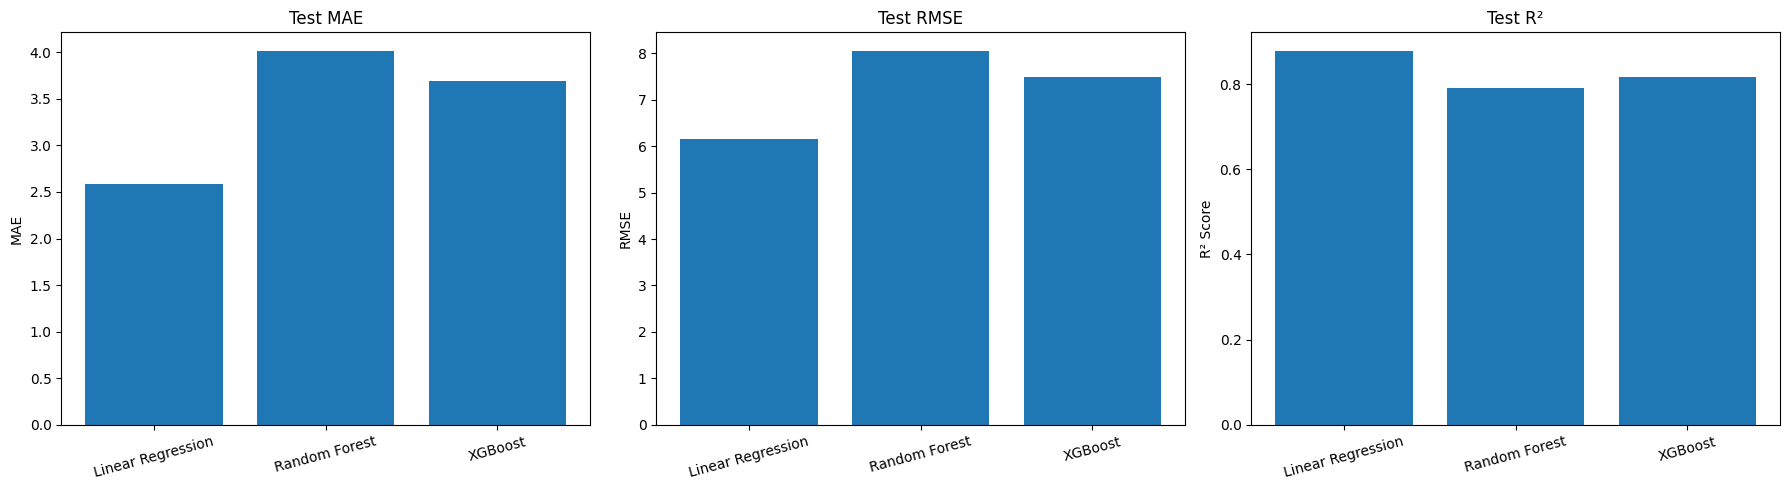

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE
axes[0].bar(comparison["Model"], comparison["MAE"])
axes[0].set_title("Test MAE")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis='x', rotation=15)

# RMSE
axes[1].bar(comparison["Model"], comparison["RMSE"])
axes[1].set_title("Test RMSE")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis='x', rotation=15)

# R²
axes[2].bar(comparison["Model"], comparison["R²"])
axes[2].set_title("Test R²")
axes[2].set_ylabel("R² Score")
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Residual Distribution

Residuals represent the difference between the actual and predicted groundwater levels.

A good regression model should produce residuals that are centered around zero without noticeable patterns, indicating that prediction errors are random rather than systematic.

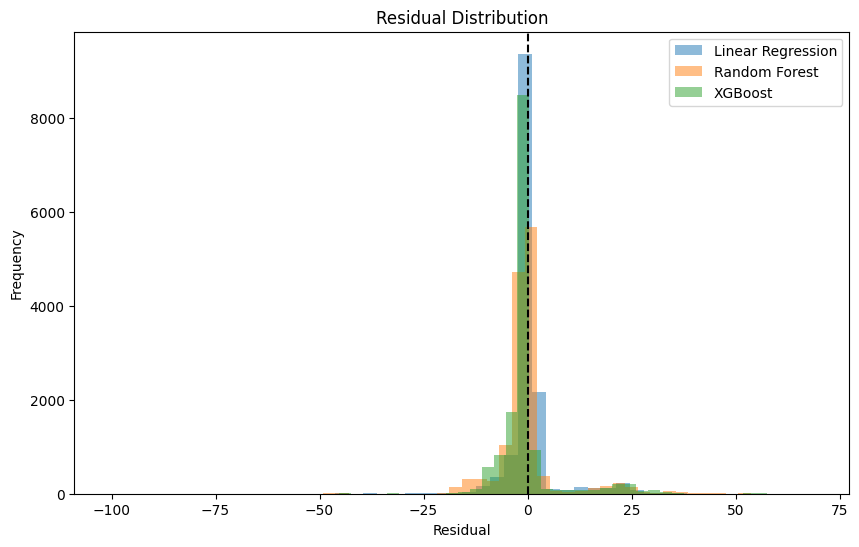

In [11]:
linear_residual = y_test - linear_pred
rf_residual = y_test - rf_pred
xgb_residual = y_test - xgb_pred

plt.figure(figsize=(10,6))

plt.hist(linear_residual, bins=50, alpha=0.5, label="Linear Regression")
plt.hist(rf_residual, bins=50, alpha=0.5, label="Random Forest")
plt.hist(xgb_residual, bins=50, alpha=0.5, label="XGBoost")

plt.axvline(0, color='black', linestyle='--')
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.legend()

plt.show()